# Homework5: Exploration of Heart Disease Data (Use UCI Dataset)
## Part 1: Confidence Intervals for a Personalized Subgroup
    1. Define a subgroup of patients based on age, sex, chest pain type, or another variable of your choice.
    2. For this subgroup:
        - Randomly select three different sample sizes (e.g., small, medium, large).
        - Calculate the proportion of patients with heart disease.
        - Construct 95% confidence intervals.
    3. Questions:
        - How does interval width change with sample size?

Based on my results, as the sample size n increased from 30 to 206, the interval width decreased drastically. This is because a larger sample size reduces the standard error, making our estimate of the population proportion more precise.
        
        - Compare your subgroup’s proportion to the overall population.
The proportion of heart disease in the subgroup for males is higher than the average in the dataset.

        - Write 2–3 sentences explaining why your subgroup may differ from the population.
The difference in proportions probably comes from biological factors or an unhealthy lifestyle (smoking or high cholesterol) compared to the female participants in the study. In this dataset, males were probably tested more than females.

## Part 2: Hypothesis Tests 

### Choose two tests that were not done in class. For each:

    - State your research question and define your null and alternative hypotheses.
#### Research question #1: Do patients with heart disease have a lower maximum heart rate than those without?
#### H0: There is no difference in the mean maximum heart rate between the two groups.
#### HA: Patients with heart disease have a significantly different mean maximum heart rate.
#### Research Question #2: Is there a significant difference in the average age of patients who have heart disease compared to those who do not?
#### H0: There is no difference in the mean age between the two groups.
#### HA: There is a significant difference in the mean age between the two groups.
   .
    - Select an appropriate test (two-proportion, one-sample t-test, two-sample t-test).
    - Compute the test and report the statistic and p-value.
#### I used a two-sample t-test for both of them.
    - Visualize the data appropriately (bar chart, histogram, or boxplot).
#### Done below.
    - Write 2–3 sentences interpreting your results.
#### My interpretation of the first test results is that the boxplot indicates patients with heart disease generally have lower maximum heart rates. The t-statistic is -3.9621, meaning I reject the null hypothesis. The p-value is very small as well.
#### My interpretation of the second test results is that the histogram shows that the heart disease group is shifted towards the right, meaning these patients are generally older. This means that age is a significant factor in heart disease in this dataset.
    
## Part 3: Type I and Type II Errors
### For one of your tests above, describe:
    - What a Type I error would mean in your context.
#### A type 1 error would give a false positive, and would happen if we say that a lower maximum heart rate is a sign of heart disease, but it actually isn't. In this context, it could mean a doctor might've seen a patient with a naturally low heart rate, and they mistakenly diagnose them with a heart condition (like athletes).
    - What a Type II error would mean.
#### A type 2 error would give us a false negative, and would happen if we fail to notice that a low maximum heart rate is a sign of heart disease. In this context, it would mean a low maximum heart rate would go undiagnosed, even though it might've been a warning signal.
    - Explain which error would be more critical for patient care or medical research.
#### Type 2 is more critical for patient care and medical research because double-checking for a false positive is always better than mistakenly ignoring a warning sign, which could be detrimental to the health of the patient. A type 1 error would just mean that the patient would probably have to go in for another appointment, which isn't as bad as the outcome of a type 2 error.

## Part 4: Sample Size and Power Planning
    - Pick one of your tests.
    - Assume α = 0.05 and desired power between 0.8–0.9.
    - Estimate effect size from your data or justify a hypothetical one.
#### I think the effect size is going to be about 0.55, using Cohen's d.
    - Compute the required sample size.
#### I computed about 47 people for the required sample size.
    - Optional: Generate a power curve showing power vs sample size for your chosen effect size.
    - Write 2–3 sentences interpreting how sample size, effect size, and power interact.
#### Sample size, effect size, and power are all connected. If the effect size is large, you don't need as many people to prove it's real. Because the study found a significant effect with the current sample size, it shows we had enough power to avoid a Type II error. In the future, if we wanted to detect even smaller differences in heart rate, we would need to increase our sample size to maintain that same level of power.

### Part 1:

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from scipy import stats
from statsmodels.stats.power import TTestIndPower

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(url, header=None)

# Add column names
df.columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [25]:
#Subgroup
subgroup = df[df['sex'] == 1.0]
total_subgroup_n = len(subgroup)

#Sample and calculate CI
sizes = [30, 100, total_subgroup_n]

for n in sizes:
    # Randomly sample n patients
    sample = subgroup.sample(n, random_state=42)
    successes = (sample['target'] > 0).sum() # Target > 0 means heart disease exists
    
# Calculate 95% CI
lower, upper = proportion_confint(count=successes, nobs=n, alpha=0.05, method='normal')
prop = successes / n
print(f"Size {n}: Proportion = {prop:.2f}, 95% CI = [{lower:.2f}, {upper:.2f}]")

Size 206: Proportion = 0.55, 95% CI = [0.49, 0.62]


### Part 2

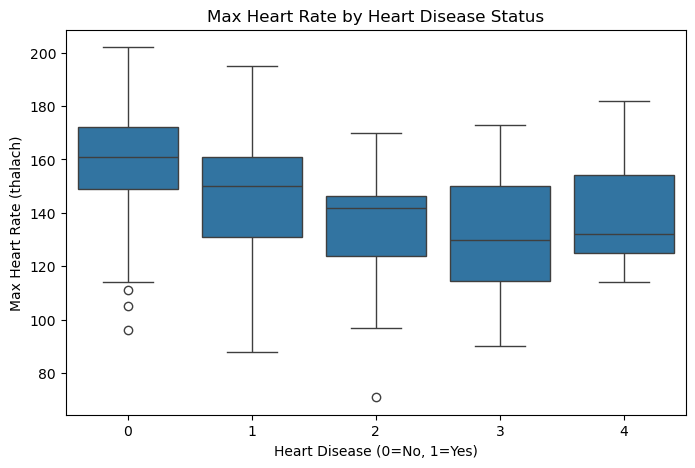

T-statistic: -3.9621
P-value: 1.0078e-04


In [26]:
#Two-sample t-test FIRST TEST
disease = df[df['target'] == 1] ['thalach']
no_disease = df[df['target'] == 0]['thalach']

t_stat, p_val = stats.ttest_ind(disease, no_disease, nan_policy='omit')

#Visualizing data
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='thalach', data=df)
plt.title("Max Heart Rate by Heart Disease Status")
plt.xlabel("Heart Disease (0=No, 1=Yes)")
plt.ylabel("Max Heart Rate (thalach)")
plt.show()
#Printing
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

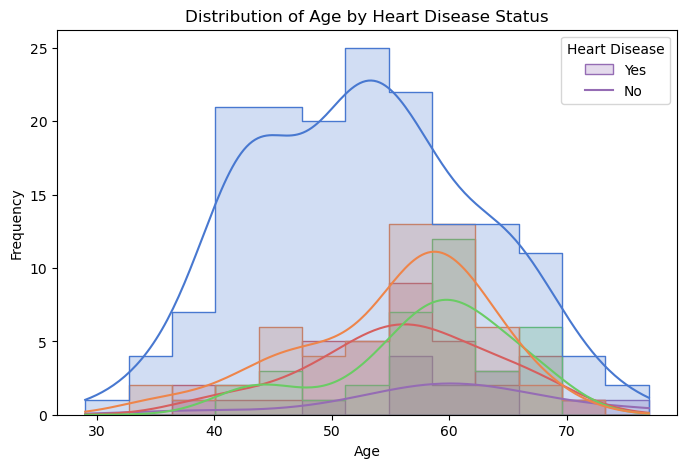

Test 2 (Age) Statistic: 3.9711
Test 2 (Age) P-value: 8.9556e-05


In [27]:
#Age and Heart Disease SECOND TEST

age_disease = df[df['target'] > 0]['age']
age_no_disease = df[df['target'] == 0]['age']

#two-Sample T-Test
t_stat_age, p_val_age = stats.ttest_ind(age_disease, age_no_disease)

#Visualization
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='target', kde=True, palette='muted', element="step")
plt.title("Distribution of Age by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend(title='Heart Disease', labels=['Yes', 'No'])
plt.show()

#print the results
print(f"Test 2 (Age) Statistic: {t_stat_age:.4f}")
print(f"Test 2 (Age) P-value: {p_val_age:.4e}")

### Part 4

In [28]:
from statsmodels.stats.power import TTestIndPower

#Calculate effect size for heart rate test
mean_diff = no_disease.mean() - disease.mean()
pooled_std = np.sqrt((no_disease.std()**2 + disease.std()**2) / 2)
effect_size = abs(mean_diff / pooled_std)

#Compute the required sample size
analysis = TTestIndPower()
required_n = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8, ratio=1.0)

print(f"Calculated Effect Size: {effect_size:.4f}")
print(f"Required sample size per group: {int(np.ceil(required_n))}")

Calculated Effect Size: 0.5901
Required sample size per group: 47
